In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv('Crop_recommendation.csv')
print(f"Shape of the dataset: {df.shape}")
df.head()

Shape of the dataset: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Check for missing values
print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

missing = df.isnull().sum()
print(missing)

print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    print("Missing values found, handle them accordingly!")

MISSING VALUES CHECK
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total Missing Values: 0
No missing values found.


In [5]:
# Check for duplicate rows
print("=" * 50)
print("DUPLICATE ROWS CHECK")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicate rows removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")

DUPLICATE ROWS CHECK
Total Duplicate Rows: 0
No duplicate rows found.


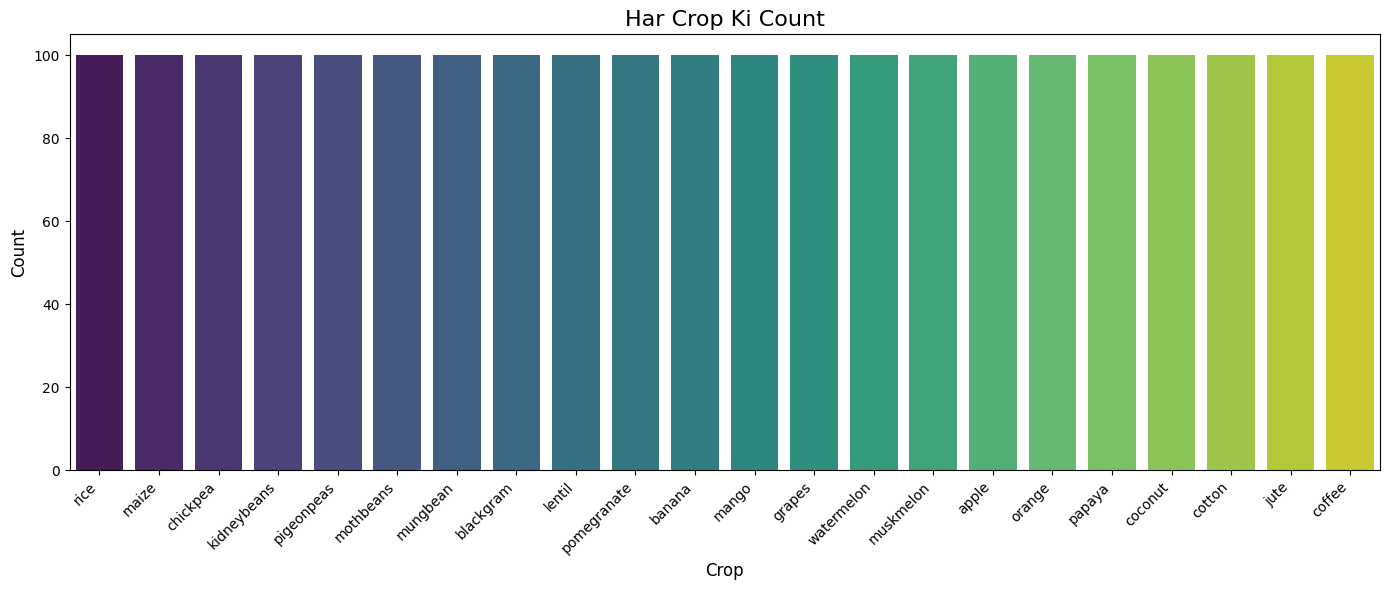

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [20]:
# Crop distribution plot
plt.figure(figsize=(14, 6))

crop_counts = df['label'].value_counts()
sns.barplot(x=crop_counts.index, y=crop_counts.values, 
            hue=crop_counts.index, palette='viridis', legend=False)

plt.title('Har Crop Ki Count', fontsize=16)
plt.xlabel('Crop', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(crop_counts)

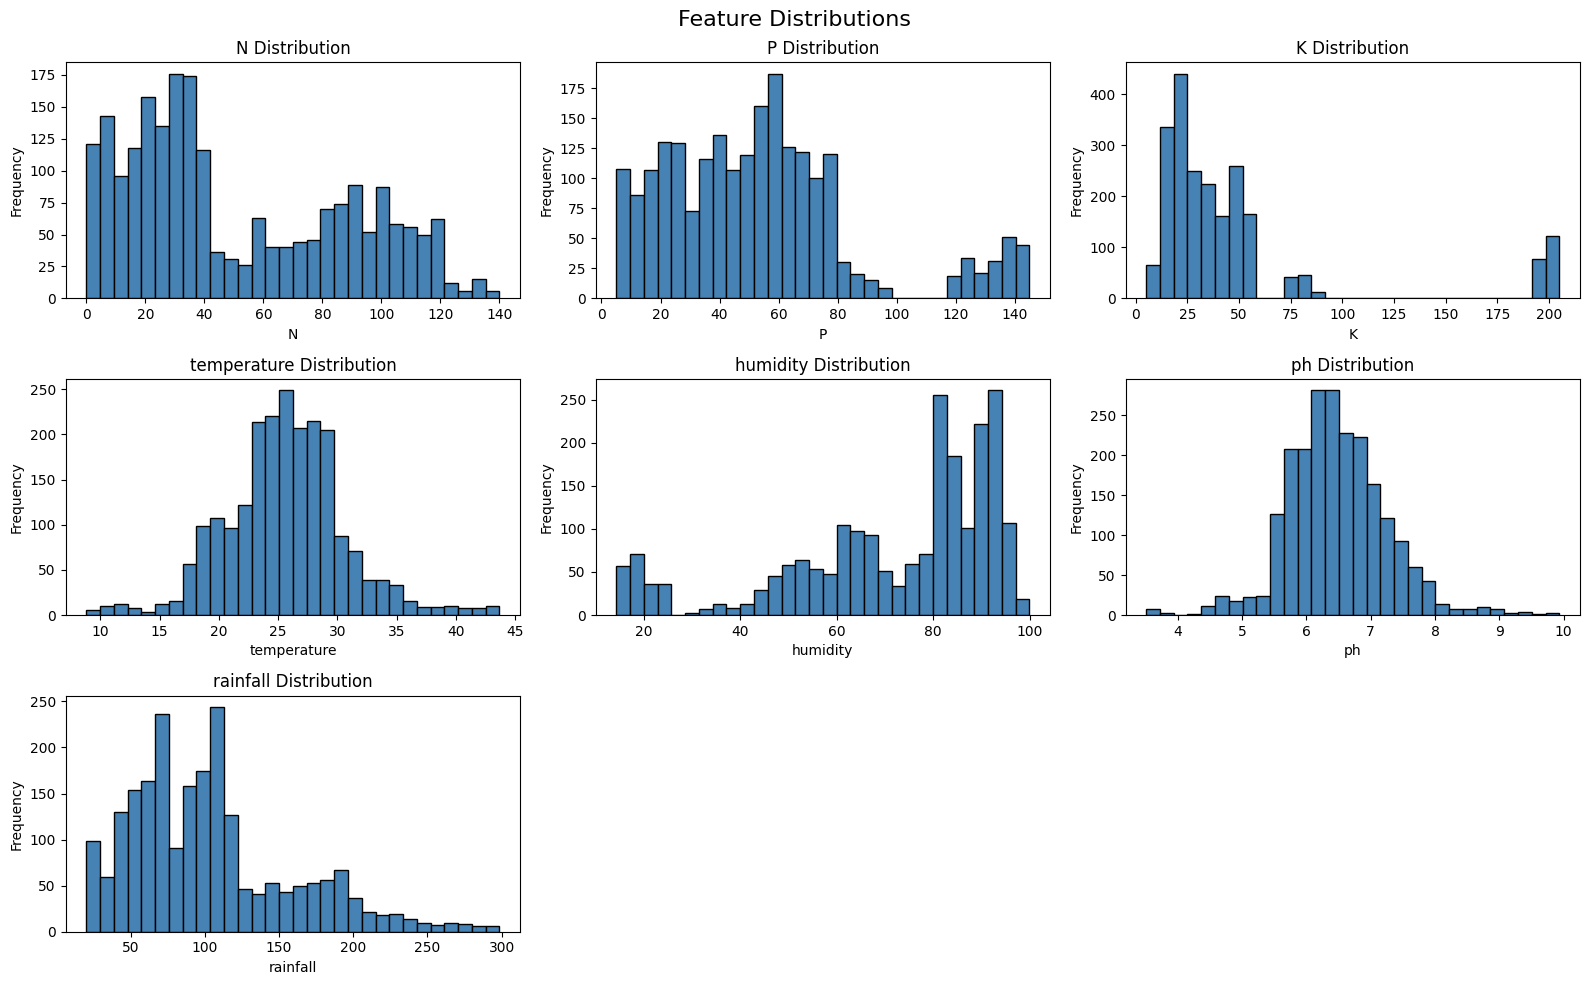

In [7]:
# Feature distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features):
    plt.subplot(3, 3, i+1)
    plt.hist(df[feature], bins=30, color='steelblue', edgecolor='black')
    plt.title(f'{feature} Distribution')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

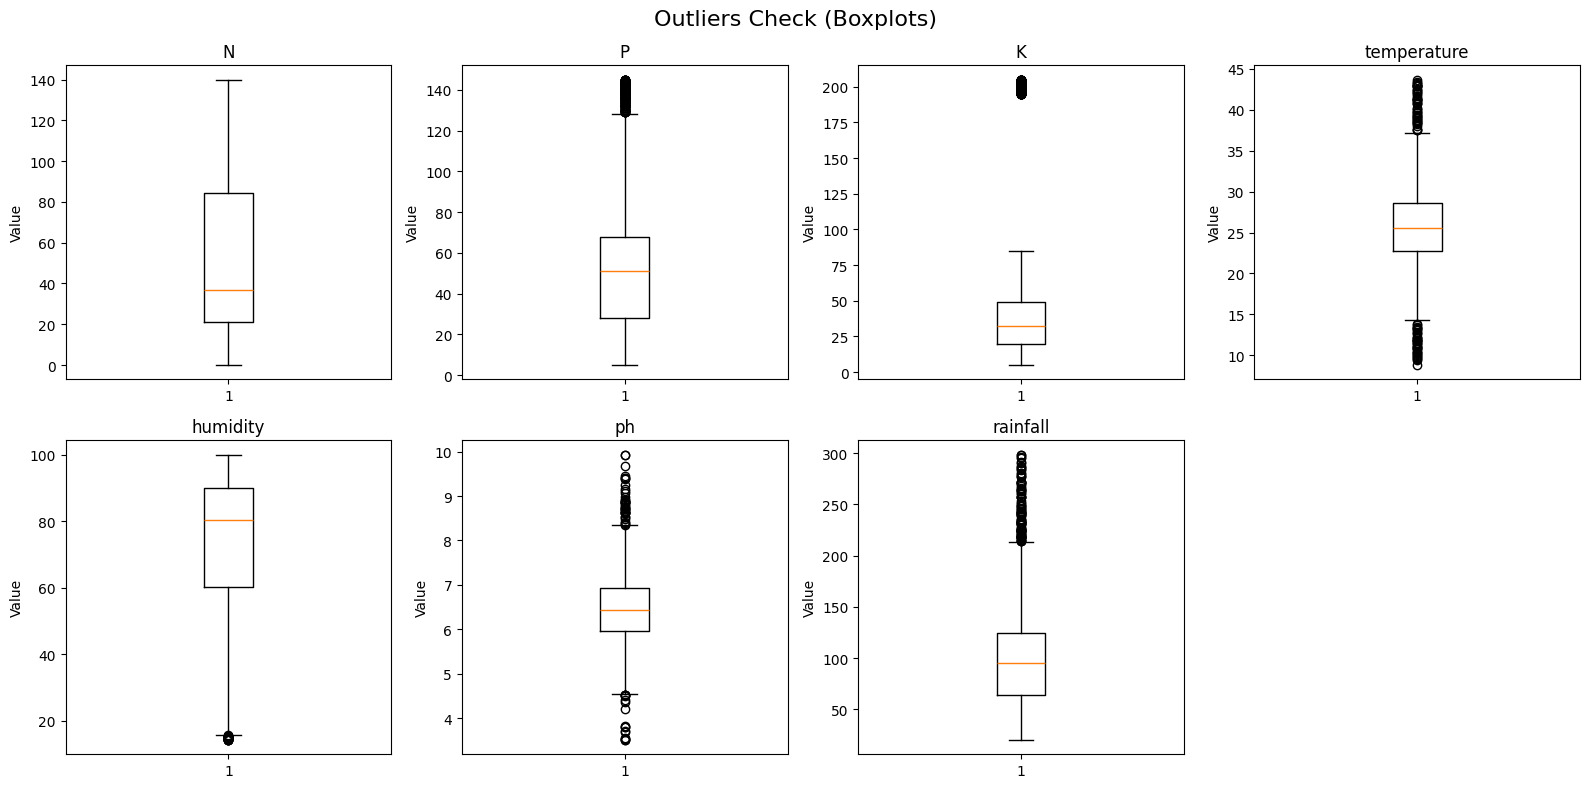

In [8]:
# Outliers dekho
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(16, 8))

for i, feature in enumerate(features):
    plt.subplot(2, 4, i+1)
    plt.boxplot(df[feature])
    plt.title(f'{feature}')
    plt.ylabel('Value')

plt.suptitle('Outliers Check (Boxplots)', fontsize=16)
plt.tight_layout()
plt.show()

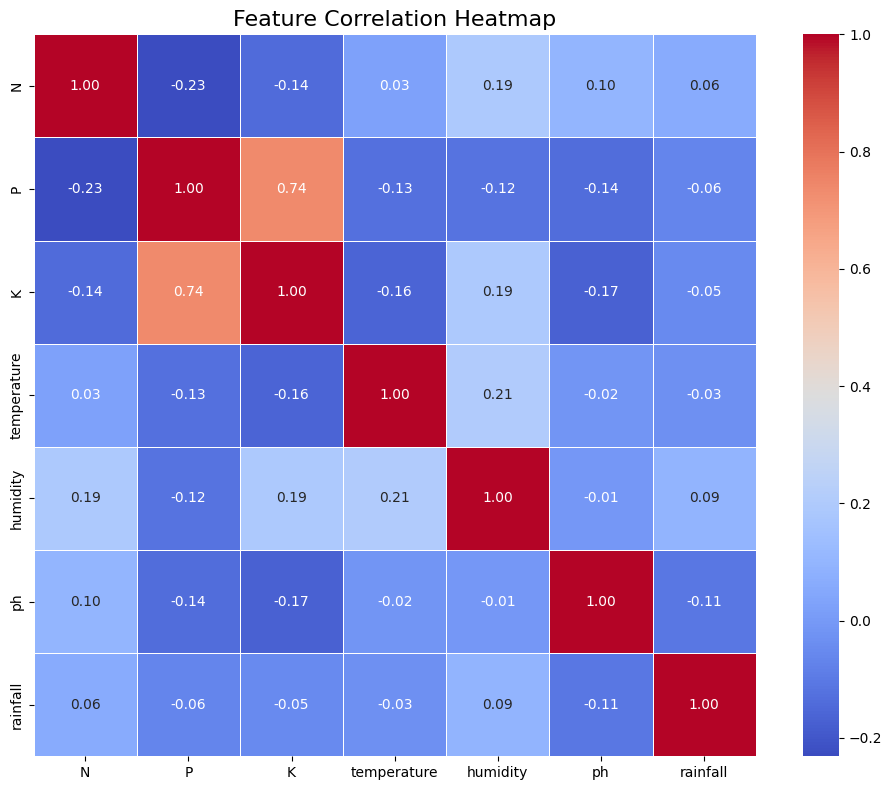

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))

correlation = df.drop('label', axis=1).corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
# X = input features, y = output (crop name)
X = df.drop('label', axis=1)
y = df['label']

print("=" * 50)
print("FEATURES & TARGET SPLIT")
print("=" * 50)
print(f"Input Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature Columns: {X.columns.tolist()}")
print(f"\nUnique Crops in Target: {y.nunique()}")

FEATURES & TARGET SPLIT
Input Features (X) shape: (2200, 7)
Target (y) shape: (2200,)

Feature Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

Unique Crops in Target: 22


In [11]:
# Label encoding for target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("=" * 50)
print("LABEL ENCODING")
print("=" * 50)
print("\nCrop Name → Number Mapping:")

for crop, number in zip(le.classes_, range(len(le.classes_))):
    print(f"  {crop} → {number}")

LABEL ENCODING

Crop Name → Number Mapping:
  apple → 0
  banana → 1
  blackgram → 2
  chickpea → 3
  coconut → 4
  coffee → 5
  cotton → 6
  grapes → 7
  jute → 8
  kidneybeans → 9
  lentil → 10
  maize → 11
  mango → 12
  mothbeans → 13
  mungbean → 14
  muskmelon → 15
  orange → 16
  papaya → 17
  pigeonpeas → 18
  pomegranate → 19
  rice → 20
  watermelon → 21


In [12]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=" * 50)
print("FEATURE SCALING")
print("=" * 50)
print("Starting")
print(X.head(3))

print("\nAfter that (Scaled):")
print(pd.DataFrame(X_scaled, columns=X.columns).head(3))
print("\n Scaling complete!")

FEATURE SCALING
Starting
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248

After that (Scaled):
          N         P         K  temperature  humidity        ph  rainfall
0  1.068797 -0.344551 -0.101688    -0.935587  0.472666  0.043302  1.810361
1  0.933329  0.140616 -0.141185    -0.759646  0.397051  0.734873  2.242058
2  0.255986  0.049647 -0.081939    -0.515898  0.486954  1.771510  2.921066

 Scaling complete!


In [13]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,       # 20% testing ke liye
    random_state=42,     # Reproducible results
    stratify=y_encoded   
)

print("=" * 50)
print("TRAIN-TEST SPLIT")
print("=" * 50)
print(f"Total Data:      {len(X_scaled)}")
print(f"Training Data:   {len(X_train)} (80%)")
print(f"Testing Data:    {len(X_test)} (20%)")
print("\n✅ Split complete!")

TRAIN-TEST SPLIT
Total Data:      2200
Training Data:   1760 (80%)
Testing Data:    440 (20%)

✅ Split complete!


In [14]:
# Model
model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    random_state=42,
    max_depth=None   
)

model.fit(X_train, y_train)

print("=" * 50)
print("MODEL TRAINING")
print("=" * 50)
print("✅ Model successfully trained!")
print(f"Total Trees: {model.n_estimators}")

MODEL TRAINING
✅ Model successfully trained!
Total Trees: 100


In [15]:
y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"Training Accuracy:  {train_acc * 100:.2f}%")
print(f"Testing Accuracy:   {test_acc * 100:.2f}%")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

MODEL EVALUATION
Training Accuracy:  100.00%
Testing Accuracy:   99.55%

--- Classification Report ---
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.0

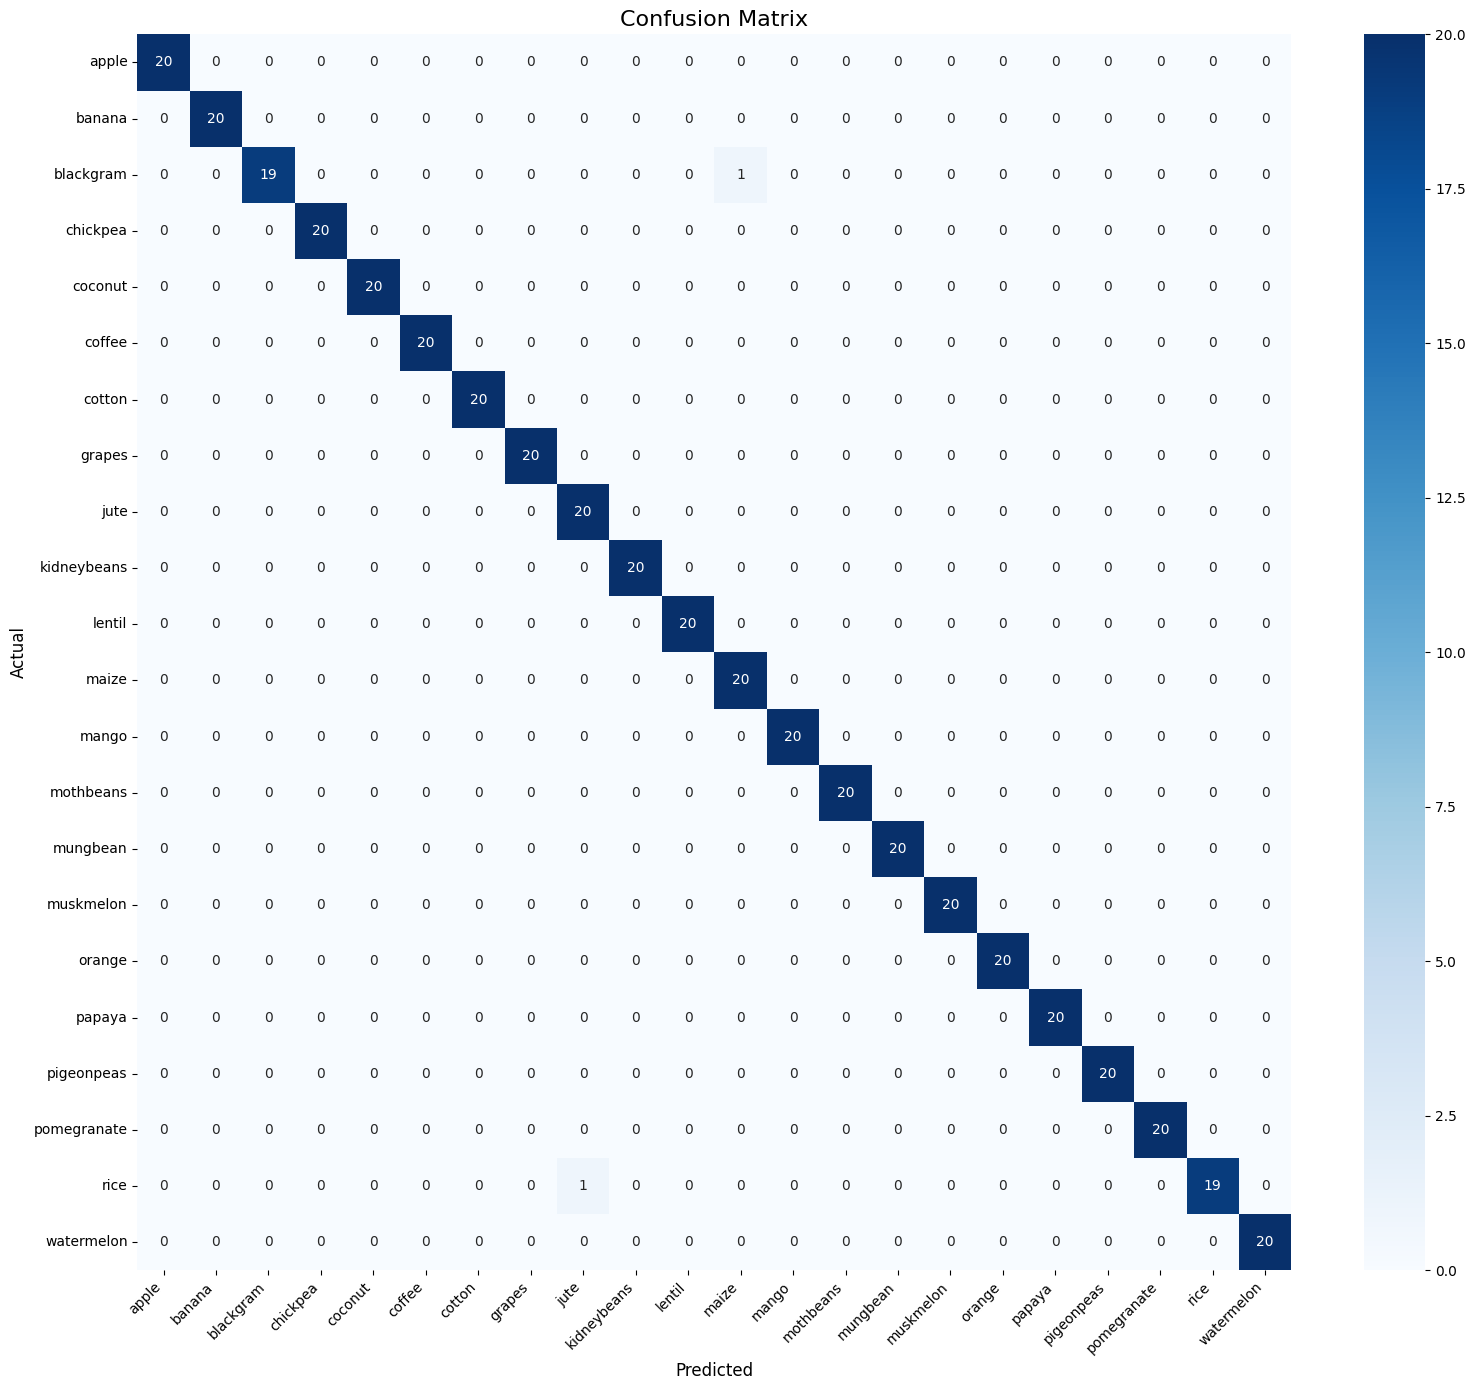

In [16]:

plt.figure(figsize=(16, 14))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

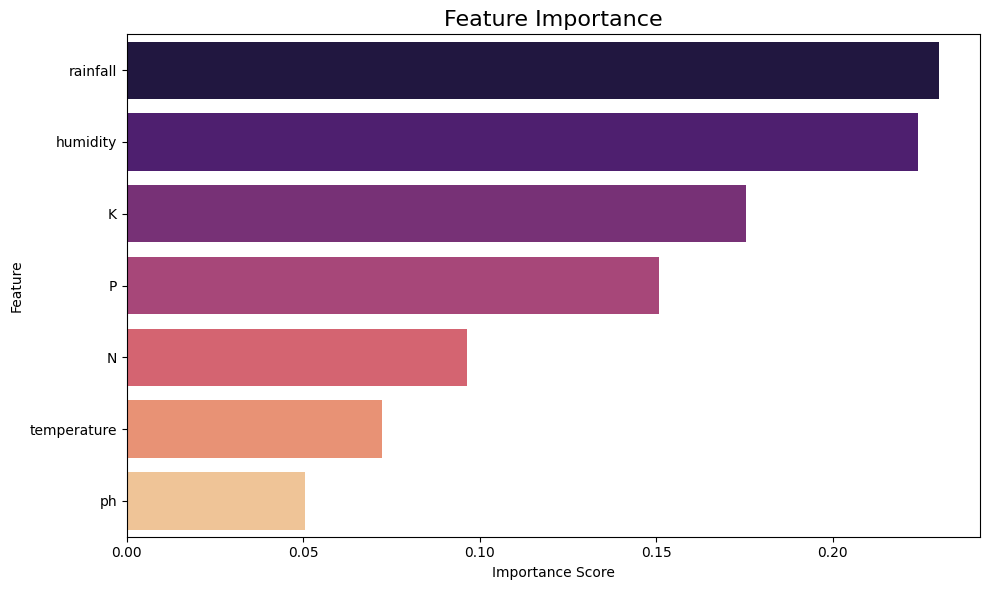

       Feature  Importance
6     rainfall    0.230184
4     humidity    0.224227
2            K    0.175393
1            P    0.150850
0            N    0.096363
3  temperature    0.072375
5           ph    0.050608


In [21]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance,
            hue='Feature', palette='magma', legend=False)

plt.title('Feature Importance', fontsize=16)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance)

In [22]:
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):
    
    # numpy array ki jagah DataFrame banao
    input_data = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall]],
                               columns=['N', 'P', 'K', 'temperature', 
                                        'humidity', 'ph', 'rainfall'])
    
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    crop_name = le.inverse_transform(prediction)[0]
    return crop_name

# Test karo
result = predict_crop(90, 42, 43, 20.8, 82, 6.5, 202)
print(f"✅ Recommended Crop: {result.upper()} 🌾")

✅ Recommended Crop: RICE 🌾


In [19]:
import pickle

with open('crop_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Model saved: crop_model.pkl")
print("Scaler saved: scaler.pkl")
print("Label Encoder saved: label_encoder.pkl")

Model saved: crop_model.pkl
Scaler saved: scaler.pkl
Label Encoder saved: label_encoder.pkl
